In [1]:
# import necessary Libraries
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')


### **Load Data**

In [2]:
print("="*50)
print("Flight Price Prediction Model")
print("EDA-Driven: Using flightType + distance")
print("="*50)

print("\nLoading data...")
flights = pd.read_csv('../data/flights.csv')
print(f"Flights Loaded: {flights.shape}")

Flight Price Prediction Model
EDA-Driven: Using flightType + distance

Loading data...
Flights Loaded: (271888, 10)


### **Data Preprocessing**

In [3]:
print("\nPreprocessing data...")

# Drop missing values
flights.dropna(inplace=True)
print(f"Shape after dropping nulls: {flights.shape}")

# Parse date features
flights['date'] = pd.to_datetime(flights['date'])
flights['month'] = flights['date'].dt.month
flights['day'] = flights['date'].dt.day
flights['day_of_week'] = flights['date'].dt.dayofweek

print("Date features extracted.")


Preprocessing data...
Shape after dropping nulls: (271888, 10)
Date features extracted.


### **EDA Validation**

In [4]:
print("\nValidating EDA findings...")

# Correlation check
print("\nCorrelation with price:")
num_cols = ['price', 'time', 'distance', 'month', 'day']
corr = flights[num_cols].corr()['price'].sort_values(ascending=False)
print(corr)

# Time vs Distance correlation
time_dist_corr = flights['time'].corr(flights['distance'])
print(f"\nTime vs Distance correlation: {time_dist_corr:.3f}")

# Agency price check
print("\nAverage Price by Agency:")
print(flights.groupby('agency')['price'].mean())

# Price by flight type
print("\nAverage Price by Flight Type:")
print(flights.groupby('flightType')['price'].mean().sort_values(ascending=False))


Validating EDA findings...

Correlation with price:
price       1.000000
distance    0.641915
time        0.641800
month      -0.000013
day        -0.003572
Name: price, dtype: float64

Time vs Distance correlation: 1.000

Average Price by Agency:
agency
CloudFy         918.896483
FlyingDrops    1186.160378
Rainbow         919.780760
Name: price, dtype: float64

Average Price by Flight Type:
flightType
firstClass    1181.067727
premium        920.392375
economic       658.443093
Name: price, dtype: float64


### **Encode Categorical Columns**

In [5]:
print("\nEncoding categorical columns...")

le_type = LabelEncoder()
flights['type_enc'] = le_type.fit_transform(flights['flightType'])

print("-> Encoding done!")
print(f"  Flight Types: {list(le_type.classes_)}")
print(f"  Encoded as : {list(range(len(le_type.classes_)))}")


Encoding categorical columns...
-> Encoding done!
  Flight Types: ['economic', 'firstClass', 'premium']
  Encoded as : [0, 1, 2]


### **Feature Selection (EDA-Driven)**

In [7]:
# Based on EDA:
# flightType → primary driver
# distance   → numerical driver (corr: 0.642)
# agency     → dropped (same prices)
# time       → dropped (perfectly corr with distance)

FEATURES = [
    'type_enc',   # Primary: flight class
    'distance',   # Numerical: route distance
    'month',      # Seasonal: peak in October
    'day',        # Day of month
    'day_of_week'   # Day of week
]
TARGET = 'price'

print(f"\nEDA-Selected Features: {FEATURES}")
print(f"Target: {TARGET}")

X = flights[FEATURES]
y = flights[TARGET]

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Price range: ${y.min():.2f} - ${y.max():.2f}")
print(f"Price mean : ${y.mean():.2f}")


EDA-Selected Features: ['type_enc', 'distance', 'month', 'day', 'day_of_week']
Target: price

X shape: (271888, 5)
y shape: (271888,)
Price range: $301.51 - $1754.17
Price mean : $957.38


### **Train Test Split**

In [8]:
print("\nSplitting data...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"-> Train size : {X_train.shape}")
print(f"-> Test size  : {X_test.shape}")


Splitting data...
-> Train size : (217510, 5)
-> Test size  : (54378, 5)


### **Scale Features**

In [9]:
print("\nScaling features...")

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("-> Scaling done!")


Scaling features...
-> Scaling done!


### **Train Models**

In [10]:
print("\nTraining models...")
print("-"*50)

models = {
    "Linear Regression" : LinearRegression(),
    "Random Forest"     : RandomForestRegressor(
                            n_estimators=100, random_state=42, n_jobs=-1
                          ),
    "Gradient Boosting" : GradientBoostingRegressor(
                            n_estimators=100, random_state=42, learning_rate=0.1
                          )
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")

    # Train
    model.fit(X_train_sc, y_train)

    # Predict
    preds = model.predict(X_test_sc)

    # Metrics
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)

    results[name] = {
        'model' : model,
        'preds' : preds,
        'MAE'   : mae,
        'RMSE'  : rmse,
        'R2'    : r2
    }

    print(f" -> MAE  : {mae:.2f}")
    print(f" -> RMSE : {rmse:.2f}")
    print(f" -> R2   : {r2:.4f}")


Training models...
--------------------------------------------------

Training Linear Regression...
 -> MAE  : 216.43
 -> RMSE : 260.76
 -> R2   : 0.4840

Training Random Forest...
 -> MAE  : 72.05
 -> RMSE : 122.19
 -> R2   : 0.8867

Training Gradient Boosting...
 -> MAE  : 96.35
 -> RMSE : 135.00
 -> R2   : 0.8617


### **Compare Models**

In [13]:
print("\n" + "="*50)
print("MODEL COMPARISON")
print("="*50)
print(f"{'Model':<20} {'MAE':>10} {'RMSE':>10} {'R2':>10}")
print("-"*55)
for name, res in results.items():
    print(f"{name:<20} {res['MAE']:>10.2f} "
          f"{res['RMSE']:>10.2f} {res['R2']:>10.4f}")


MODEL COMPARISON
Model                       MAE       RMSE         R2
-------------------------------------------------------
Linear Regression        216.43     260.76     0.4840
Random Forest             72.05     122.19     0.8867
Gradient Boosting         96.35     135.00     0.8617


### **Select Best Model**

In [14]:
best_name  = max(results, key=lambda k: results[k]['R2'])
best_model = results[best_name]['model']
best_preds = results[best_name]['preds']

print(f"\nBest Model : {best_name}")
print(f" ->  R2 Score   : {results[best_name]['R2']:.4f}")
print(f" ->  MAE        : {results[best_name]['MAE']:.2f}")
print(f" ->  RMSE       : {results[best_name]['RMSE']:.2f}")


Best Model : Random Forest
 ->  R2 Score   : 0.8867
 ->  MAE        : 72.05
 ->  RMSE       : 122.19


### **Visualizations**


Generating plots...


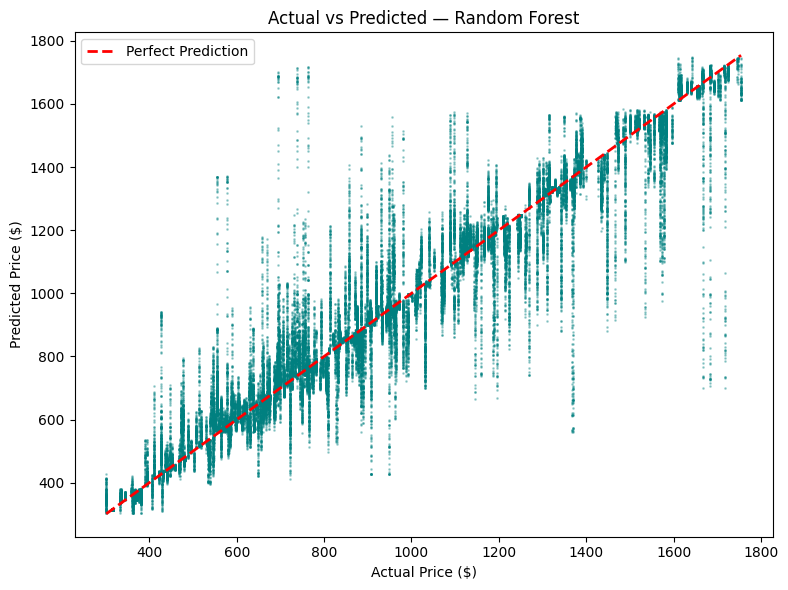

-> Actual vs Predicted plot saved!


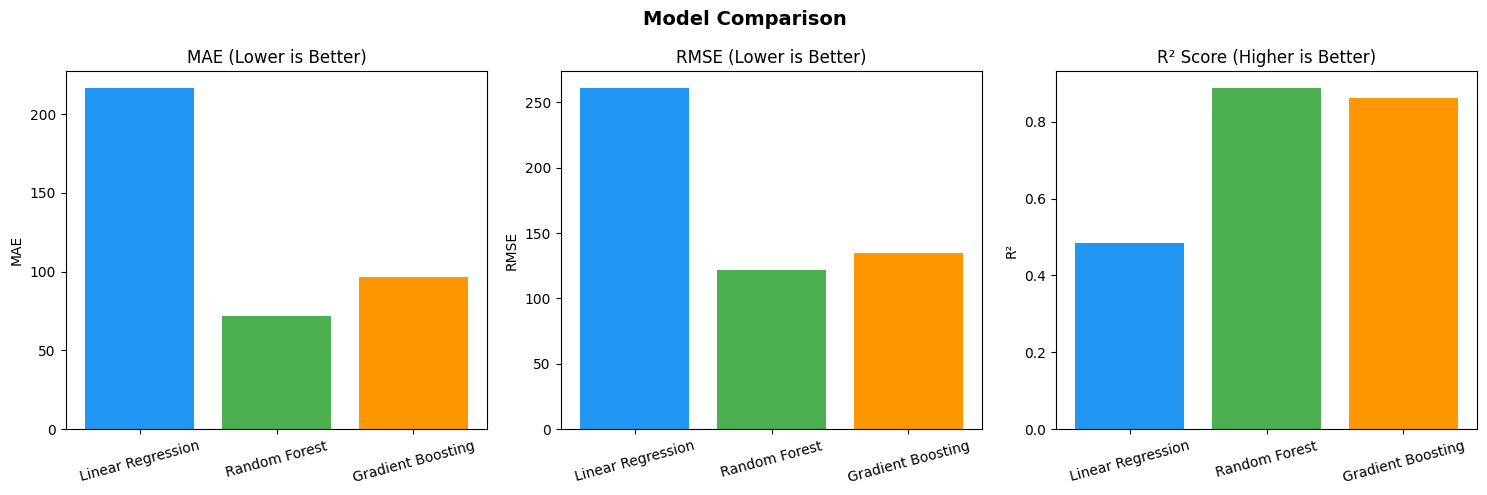

-> Model comparison plot saved!


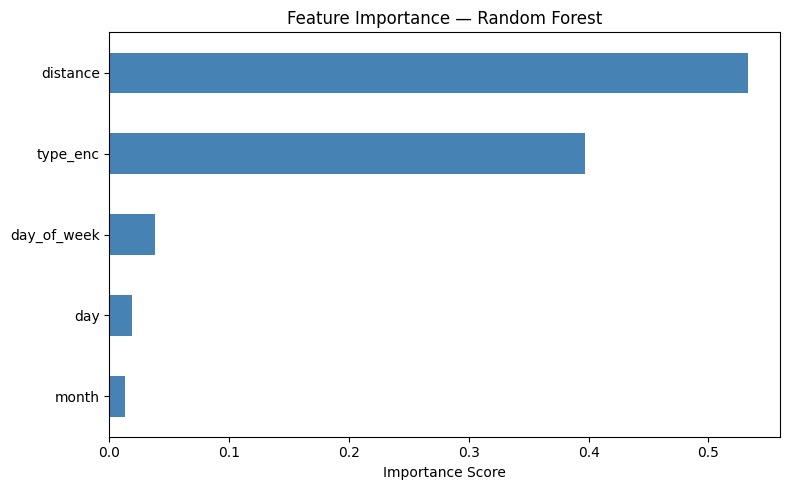

-> Feature importance plot saved!


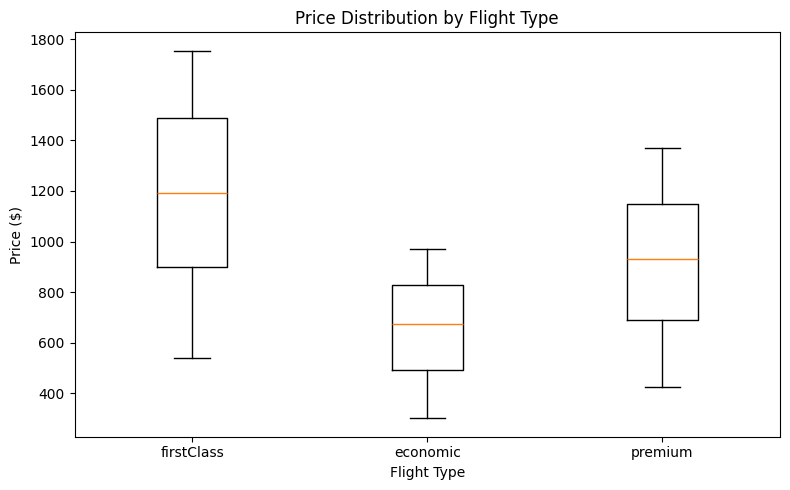

-> Price by flight type plot saved!


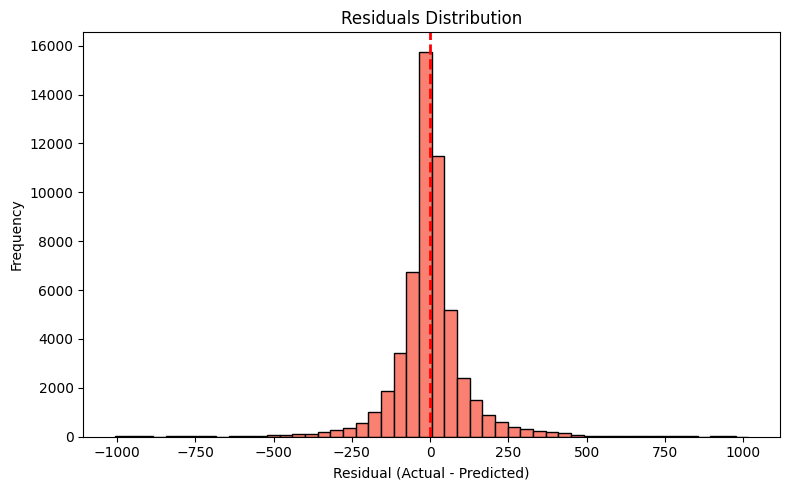

-> Residuals plot saved!


In [15]:
print("\nGenerating plots...")
os.makedirs('models/plots', exist_ok=True)

# Plot 1: Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, best_preds,
            alpha=0.3, color='teal', s=1)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title(f'Actual vs Predicted — {best_name}')
plt.legend()
plt.tight_layout()
plt.savefig('models/plots/actual_vs_predicted.png', dpi=150)
plt.show()
print("-> Actual vs Predicted plot saved!")

# Plot 2: Model Comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Model Comparison', fontsize=14, fontweight='bold')

model_names = list(results.keys())
maes  = [results[m]['MAE']  for m in model_names]
rmses = [results[m]['RMSE'] for m in model_names]
r2s   = [results[m]['R2']   for m in model_names]
colors = ['#2196F3', '#4CAF50', '#FF9800']

axes[0].bar(model_names, maes, color=colors)
axes[0].set_title('MAE (Lower is Better)')
axes[0].set_ylabel('MAE')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(model_names, rmses, color=colors)
axes[1].set_title('RMSE (Lower is Better)')
axes[1].set_ylabel('RMSE')
axes[1].tick_params(axis='x', rotation=15)

axes[2].bar(model_names, r2s, color=colors)
axes[2].set_title('R² Score (Higher is Better)')
axes[2].set_ylabel('R²')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('models/plots/model_comparison.png', dpi=150)
plt.show()
print("-> Model comparison plot saved!")

# Plot 3: Feature Importance
if hasattr(best_model, 'feature_importances_'):
    fi = pd.Series(
        best_model.feature_importances_,
        index=FEATURES
    ).sort_values(ascending=True)

    plt.figure(figsize=(8, 5))
    fi.plot(kind='barh', color='steelblue')
    plt.title(f'Feature Importance — {best_name}')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.savefig('models/plots/feature_importance.png', dpi=150)
    plt.show()
    print("-> Feature importance plot saved!")

# Plot 4: Price by Flight Type
plt.figure(figsize=(8, 5))
flight_types = flights['flightType'].unique()
price_by_type = [
    flights[flights['flightType'] == ft]['price'].values
    for ft in flight_types
]
plt.boxplot(price_by_type, labels=flight_types)
plt.title('Price Distribution by Flight Type')
plt.xlabel('Flight Type')
plt.ylabel('Price ($)')
plt.tight_layout()
plt.savefig('models/plots/price_by_flight_type.png', dpi=150)
plt.show()
print("-> Price by flight type plot saved!")

# Plot 5: Residuals
residuals = y_test - best_preds
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=50,
         color='salmon', edgecolor='black')
plt.axvline(x=0, color='red',
            linestyle='--', linewidth=2)
plt.title('Residuals Distribution')
plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('models/plots/residuals.png', dpi=150)
plt.show()
print("-> Residuals plot saved!")

### **Save Model & Artifacts**

In [16]:
print("\nSaving model artifacts...")

# Save model
joblib.dump(best_model, 'models/flight_price_model.pkl')
print("-> Model saved!")

# Save scaler
joblib.dump(scaler, 'models/flight_price_scaler.pkl')
print("-> Scaler saved!")

# Save encoder
joblib.dump(le_type, 'models/flight_type_encoder.pkl')
print("-> Encoder saved!")

# Save features list
joblib.dump(FEATURES, 'models/flight_price_features.pkl')
print("-> Features saved!")

# Save model info
model_info = {
    'best_model'  : best_name,
    'r2_score'    : results[best_name]['R2'],
    'mae'         : results[best_name]['MAE'],
    'rmse'        : results[best_name]['RMSE'],
    'features'    : FEATURES,
    'flight_types': list(le_type.classes_),
    'eda_insights': {
        'primary_driver'     : 'flightType',
        'numerical_driver'   : 'distance',
        'dropped_agency'     : 'same prices across agencies',
        'dropped_time'       : 'perfectly correlated with distance',
        'seasonal_peak'      : 'October',
        'seasonal_low'       : 'August'
    }
}
joblib.dump(model_info, 'models/flight_model_info.pkl')
print("-> Model info saved!")


Saving model artifacts...
-> Model saved!
-> Scaler saved!
-> Encoder saved!
-> Features saved!
-> Model info saved!


### **Test The Saved Model**

In [17]:
print("\nTesting saved model with sample inputs...")

loaded_model   = joblib.load('models/flight_price_model.pkl')
loaded_scaler  = joblib.load('models/flight_price_scaler.pkl')
loaded_encoder = joblib.load('models/flight_type_encoder.pkl')

# Test all 3 flight types
test_cases = [
    {'flightType': 'firstClass',  'distance': 676.53, 'month': 9,  'day': 26, 'dayofweek': 3},
    {'flightType': 'premium',     'distance': 676.53, 'month': 9,  'day': 26, 'dayofweek': 3},
    {'flightType': 'economic',    'distance': 676.53, 'month': 9,  'day': 26, 'dayofweek': 3},
    {'flightType': 'firstClass',  'distance': 1500.0, 'month': 10, 'day': 15, 'dayofweek': 1},
]

print("\nSample Predictions:")
print("-"*55)
print(f"{'Flight Type':<15} {'Distance':>10} {'Month':>6} {'Price':>12}")
print("-"*55)

for case in test_cases:
    type_enc = loaded_encoder.transform([case['flightType']])[0]

    sample = np.array([[
        type_enc,
        case['distance'],
        case['month'],
        case['day'],
        case['dayofweek']
    ]])

    sample_sc  = loaded_scaler.transform(sample)
    prediction = loaded_model.predict(sample_sc)[0]

    print(f"{case['flightType']:<15} "
          f"{case['distance']:>10.1f} "
          f"{case['month']:>6} "
          f"${prediction:>10.2f}")

print("\n" + "="*50)
print("-> FLIGHT PRICE MODEL COMPLETE!")
print("="*50)


Testing saved model with sample inputs...

Sample Predictions:
-------------------------------------------------------
Flight Type       Distance  Month        Price
-------------------------------------------------------
firstClass           676.5      9 $   1288.76
premium              676.5      9 $   1003.06
economic             676.5      9 $    693.66
firstClass          1500.0     10 $   1639.24

-> FLIGHT PRICE MODEL COMPLETE!
